# Herbie download scriptt

In [1]:
import os
from herbie import Herbie, paint
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
from metpy.plots import USCOUNTIES
from scipy.ndimage import gaussian_filter
import imageio  
from datetime import datetime, timedelta
import warnings 
warnings.filterwarnings('ignore')
from dask.distributed import Client
client = Client(memory_limit="35GB")

# GRIB Key nonsense. Doing two herbie pulls, saving as nc files, then merging the two

In [2]:
start_time = pd.to_datetime('2025-05-10 12:00')
pcp_list = []

for fxx in range(0,19):
    H = Herbie(start_time, model='hrrr', product='prs', priority='google', fxx=fxx)
    path_v = H.download(f'UGRD:10 m above ground:|VGRD:10 m above ground')
    ds_pcp = xr.open_dataset(path_v, engine='cfgrib')
    pcp_list.append(ds_pcp)
pcp2 = xr.concat(pcp_list, dim="step")


✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F00 ┊ GRIB2 @ google ┊ IDX @ google
👨🏻‍🏭 Created directory: [/home/bweart1/data/hrrr/20250510]
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F01 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F02 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F03 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F04 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F05 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F06 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F07 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F08 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F09 ┊ GRIB2 @ google ┊ IDX 

In [4]:
start_time = pd.to_datetime('2025-05-10 12:00')
pcp_list = []

for fxx in range(0,19):
    H = Herbie(start_time, model='hrrr', product='prs', priority='google', fxx=fxx)
    path_v = H.download(f':DPT:2 m above ground:|:TMP:2 m above ground:')
    ds_pcp = xr.open_dataset(path_v, engine='cfgrib')
    pcp_list.append(ds_pcp)
pcp = xr.concat(pcp_list, dim="step")


✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F00 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F01 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F02 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F03 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F04 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F05 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F06 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F07 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F08 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 12:00 UTC F09 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-May-10 1

In [6]:
merged = xr.merge([pcp, pcp2], compat='override')
enc = {k: {"zlib": True, "complevel": 4} for k in list(pcp2.data_vars) + list(pcp2.coords)}
merged.to_netcdf("hrrr_lake_breeze_data_5_10_m.nc", encoding=enc)


# Run imports and start from here if restarting notebook kernel

In [ ]:
ds = xr.open_dataset("hrrr_lake_breeze_data_5_10_m.nc")
ds

# Calulation of Divergence with MetPy

In [3]:
import metpy.calc as mpcalc
from metpy.xarray import grid_deltas_from_dataarray  # helper for dx, dy

# 1) Attach CF/projection metadata + units to your Dataset
def calc_conv_div(ds):
    ds = ds.metpy.parse_cf()
    ds = ds.metpy.quantify()
    
    # 2) Grab winds (will carry units)
    u = ds['u10']
    v = ds['v10']
    
    # 3) Grid spacing in meters (uses projection from metpy_crs)
    dx, dy = grid_deltas_from_dataarray(u)  # returns Quantities with units
    
    # 4) Divergence (1/s), then drop units if you want plain floats
    div = mpcalc.divergence(u, v, dx=dx, dy=dy)           # Quantity
    ds['div'] = div.metpy.dequantify()                   # plain ndarray
    ds['div'].attrs['units'] = '1/s'
    return ds
lb = calc_conv_div(ds)

# Looking at raw conv fields for a known lake-breeze day

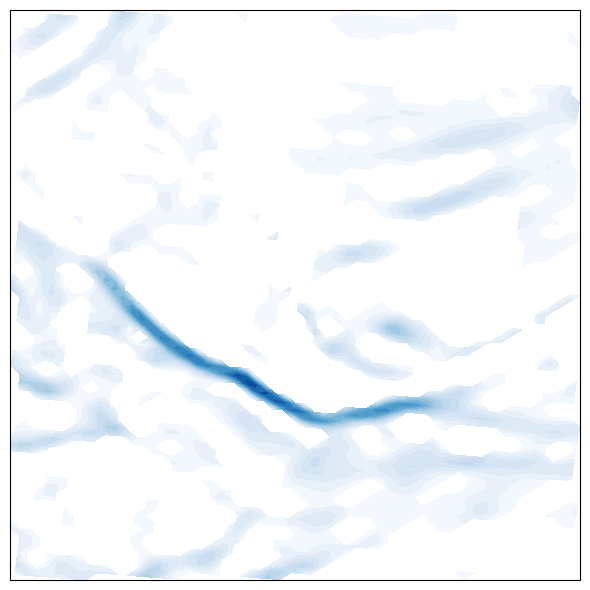

In [9]:
step_idx = 5
div = lb['div'].isel(step=step_idx)
u = lb['u10'].isel(step=step_idx)
v = lb['v10'].isel(step=step_idx)
lat2d = lb['latitude']
lon2d = lb['longitude']

buffer = 1
# Define 1°×1° box around Chicago 
center_lat, center_lon = 41.8781, -87.6298
lat_min, lat_max = center_lat - buffer, center_lat + buffer
lon_min, lon_max = center_lon - buffer, center_lon + buffer

# Wrap longitudes to [-180, 180] 
lon_wrapped = (lon2d + 180) % 360 - 180

# Mask box 
mask = (
    (lat2d >= lat_min) & (lat2d <= lat_max) &
    (lon_wrapped >= lon_min) & (lon_wrapped <= lon_max)
)
div_box = div.where(mask)
u_box = u.where(mask)
v_box = v.where(mask)

# Keep only convergence 
conv_box = div_box.where(div_box < 0)

# ---- Define levels (only negative) ----
vmin = np.nanmin(conv_box.values)
vmax = 0  # top of range at zero
if not np.isfinite(vmin):
    vmin = -1e-5
levels = np.linspace(vmin, vmax, 21)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Filled contours for convergence only
cf = ax.contourf(
    lon_wrapped, lat2d, conv_box,
    levels=levels, cmap='Blues_r', extend='min',
    transform=ccrs.PlateCarree()
)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

vt = pcp['valid_time'].isel(step=step_idx).values if 'valid_time' in pcp else None
title_time = np.datetime_as_string(vt, unit='m') if vt is not None else f"step={step_idx}"
# ax.set_title(f"Lake Breeze Convergence + 10 m Wind ({title_time})", fontsize=12)

plt.tight_layout()
plt.savefig('lake_breeze_17z.png',dpi=300,bbox_inches='tight')
plt.show()


In [5]:
import cv2
from skimage.util import random_noise

In [ ]:
img = cv2.imread("lake_breeze_17z.png")  # Reads as BGR by default
img_uint8 = img.astype(np.uint8)

In [49]:
step_idx = 4
div = np.where(pcp.div < 0)
field = pcp['div'].isel(step=step_idx)

lat2d, lon2d = lb['latitude'], lb['longitude']

center_lat, center_lon = 41.8781, -87.6298
lat_min, lat_max = center_lat - 1, center_lat + 1
lon_min, lon_max = center_lon - 1, center_lon + 1

lon_wrapped = (lon2d + 180) % 360 - 180
mask = ((lat2d >= lat_min) & (lat2d <= lat_max) &
        (lon_wrapped >= lon_min) & (lon_wrapped <= lon_max))

field_box = field.where(mask, drop=True)
lat_box = lat2d.where(mask, drop=True)
lon_box = lon_wrapped.where(mask, drop=True)

A = field_box.values.astype(np.float32)
A = np.nan_to_num(A, nan=np.nanmedian(A))

# --- Sobel (3×3 kernel) ---
sx = cv2.Sobel(A, cv2.CV_32F, 1, 0, ksize=3)
sy = cv2.Sobel(A, cv2.CV_32F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sx, sy)

# --- Scharr (better rotational accuracy) ---
scharrx = cv2.Scharr(A, cv2.CV_32F, 1, 0)
scharry = cv2.Scharr(A, cv2.CV_32F, 0, 1)
scharr_mag = cv2.magnitude(scharrx, scharry)

# --- Laplacian (second derivative) ---
lap = cv2.Laplacian(A, cv2.CV_32F, ksize=3)
lap_mag = np.abs(lap)

# --- Canny (binary edges) ---
# scale A to 0–255 uint8 before Canny
A_u8 = cv2.normalize(A, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
canny_edges = cv2.Canny(A_u8, 50, 150)

# --- Normalize each to 0–255 for consistent plotting ---
def norm255(img): return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

sobel_u8 = norm255(sobel_mag)
scharr_u8 = norm255(scharr_mag)
lap_u8 = norm255(lap_mag)

# --- Plot 2×2 comparison grid ---
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1); plt.title("Sobel"); plt.imshow(sobel_u8, cmap='gray'); plt.axis('off')
plt.subplot(2, 2, 2); plt.title("Scharr"); plt.imshow(scharr_u8, cmap='gray'); plt.axis('off')
plt.subplot(2, 2, 3); plt.title("Laplacian"); plt.imshow(lap_u8, cmap='gray'); plt.axis('off')
plt.subplot(2, 2, 4); plt.title("Canny"); plt.imshow(canny_edges, cmap='gray'); plt.axis('off')
plt.suptitle("Edge Detectors on Divergence Field (±1° around Chicago)")
plt.tight_layout()
plt.show()


AttributeError: 'tuple' object has no attribute 'where'

# Messing around with different edge detection methods

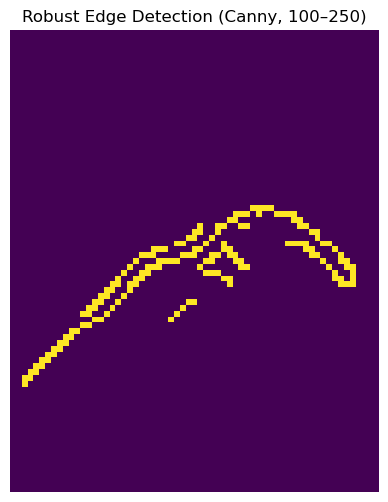

In [42]:
# --- Field around Chicago (as before) ---
step_idx = 4
field = lb['div'].isel(step=step_idx)
lat2d, lon2d = lb['latitude'], pcp['longitude']
center_lat, center_lon = 41.8781, -87.6298
lat_min, lat_max = center_lat - 1, center_lat + 1
lon_min, lon_max = center_lon - 1, center_lon + 1

lon_wrapped = (lon2d + 180) % 360 - 180
mask = ((lat2d >= lat_min) & (lat2d <= lat_max) &
        (lon_wrapped >= lon_min) & (lon_wrapped <= lon_max))
field_box = field.where(mask, drop=True)

# Prepare array
A = field_box.values.astype(np.float32)
A = np.nan_to_num(A, nan=np.nanmedian(A))
A_u8 = cv2.normalize(A, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# --- Robust edges using high Canny thresholds ---
# Tune these numbers! Try (50,150), (75,200), (100,250), (150,300)
edges_strong = cv2.Canny(A_u8, threshold1=195, threshold2=300, apertureSize=3, L2gradient=True)

plt.figure(figsize=(6,6))
plt.title("Robust Edge Detection (Canny, 100–250)")
plt.imshow(edges_strong, cmap='viridis')
plt.axis('off')
plt.show()


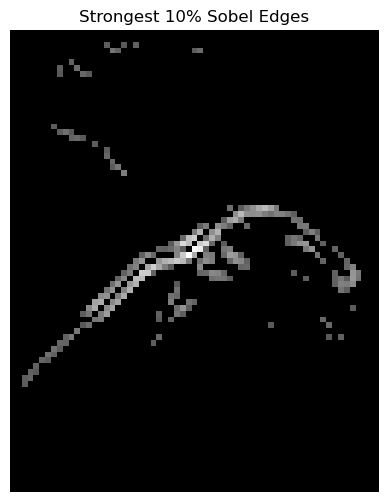

In [47]:
# Sobel magnitude (same A as above)
sx = cv2.Sobel(A, cv2.CV_32F, 1, 0, ksize=3)
sy = cv2.Sobel(A, cv2.CV_32F, 0, 1, ksize=3)
mag = cv2.magnitude(sx, sy)

# Keep only strongest edges (above, e.g., 90th percentile)
thresh = np.percentile(mag, 95)
robust_edges = np.where(mag >= thresh, mag, 0)

# Normalize to uint8 for visualization
robust_edges_u8 = cv2.normalize(robust_edges, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.title("Strongest 10% Sobel Edges")
plt.imshow(robust_edges_u8, cmap='gray')
plt.axis('off')
plt.show()


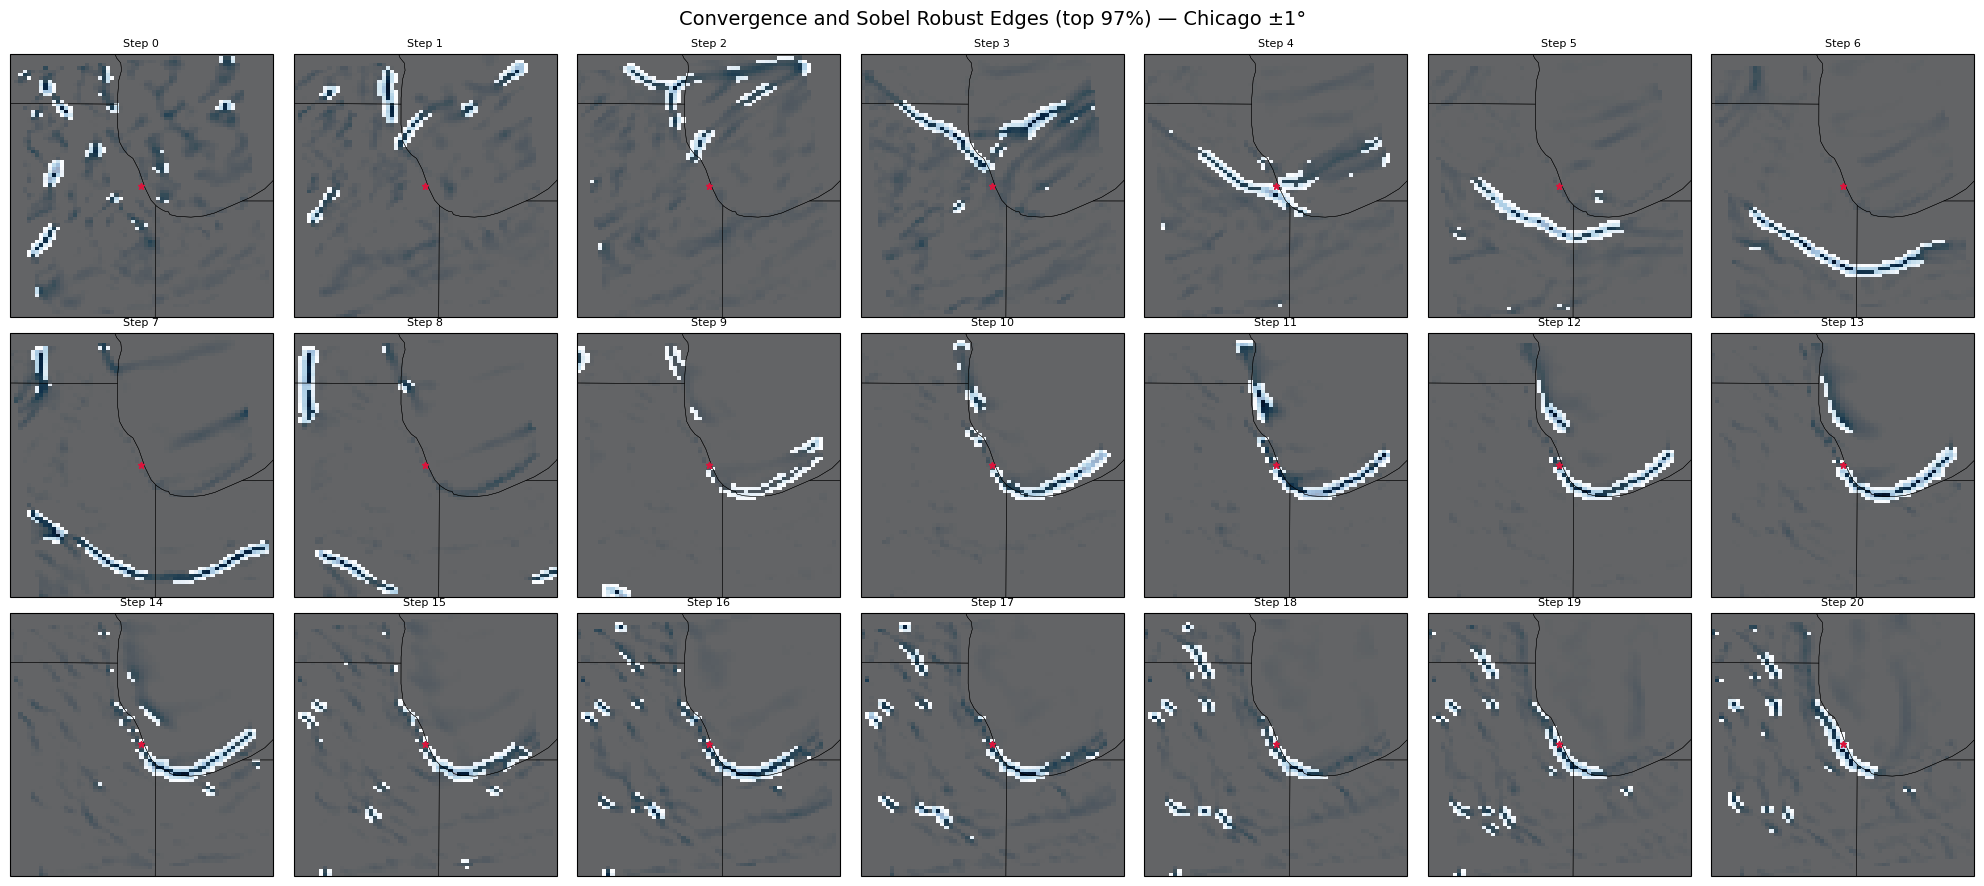

In [73]:
KSIZE = 3
PCT   = 97
nsteps = 21
ncols  = 7
nrows  = int(np.ceil(nsteps / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(20, 9),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for i in range(nsteps):
    # --- Field and mask ---
    field = pcp['div'].isel(step=i)
    mask = ((lat2d >= lat_min) & (lat2d <= lat_max) &
            (lon_wrapped >= lon_min) & (lon_wrapped <= lon_max))
    field_box = field.where(mask, drop=True)
    lat_box = lat2d.where(mask, drop=True)
    lon_box = lon_wrapped.where(mask, drop=True)
    if field_box.size == 0 or np.all(np.isnan(field_box)):
        continue

    # --- Convergence only ---
    field_conv = field_box.where(field_box < 0, 0)
    A = field_conv.values.astype(np.float32)

    # --- Sobel & threshold ---
    sx = cv2.Sobel(A, cv2.CV_32F, 1, 0, ksize=KSIZE)
    sy = cv2.Sobel(A, cv2.CV_32F, 0, 1, ksize=KSIZE)
    mag = cv2.magnitude(sx, sy)
    thr = np.percentile(mag, PCT)
    edges_mask = (mag >= thr).astype(np.uint8)

    # --- Plot on Cartopy axis ---
    ax = axes[i]
    xmin, xmax = np.nanmin(lon_box.values), np.nanmax(lon_box.values)
    ymin, ymax = np.nanmin(lat_box.values), np.nanmax(lat_box.values)
    origin = 'lower'
    if lat_box.values.ndim == 2 and lat_box.shape[0] > 1:
        if lat_box.values[0, 0] > lat_box.values[-1, 0]:
            origin = 'upper'

    ax.imshow(A, cmap='Blues_r', origin=origin,
              extent=[xmin, xmax, ymin, ymax], transform=ccrs.PlateCarree())
    ax.imshow(edges_mask, cmap='gray', origin=origin,
              extent=[xmin, xmax, ymin, ymax], transform=ccrs.PlateCarree(), alpha=0.6)

    # Add map features
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.LAKES.with_scale('50m'), edgecolor='k', facecolor='none', linewidth=0.3)

    ax.plot(center_lon, center_lat, marker='*', color='crimson',
            markersize=5, transform=ccrs.PlateCarree())
    ax.set_extent([xmin, xmax, ymin, ymax])
    ax.set_title(f"Step {i}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Convergence and Sobel Robust Edges (top 97%) — Chicago ±1°", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('LB_SOBEL_MAY_10th.png',dpi=300, bbox_inches='tight')
plt.show()


# Best working iteration of this so far has Sobel with 3x3 kernel, 95th percentile thresholding, and some other cool stuff

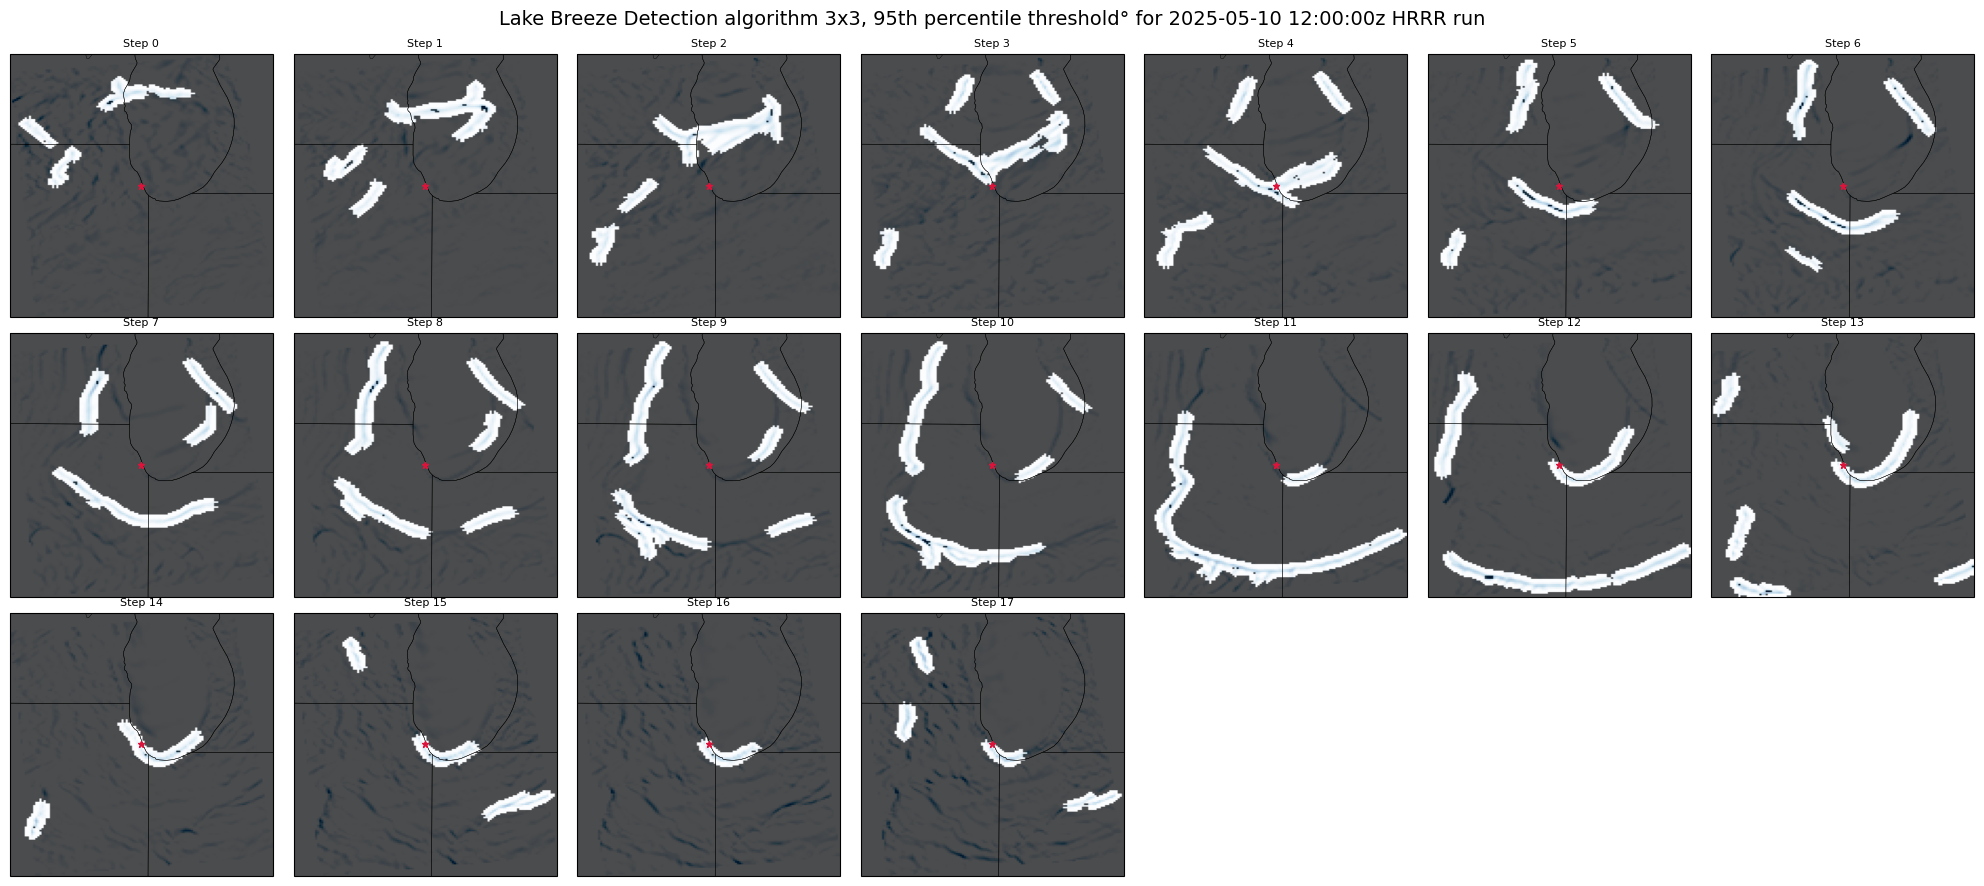

In [6]:
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects

KSIZE = 3 # Size of the Sobel Kernel
PCT   = 95 # Percentile to threshold by
nsteps = 18 # How many timesteps are there
ncols  = 7 # Plotting stuff
nrows  = int(np.ceil(nsteps / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(20, 9),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for i in range(nsteps):
    # --- Field and mask ---
    field = pcp['div'].isel(step=i)  #Loops through timesteps 
    mask = ((lat2d >= lat_min) & (lat2d <= lat_max) &
            (lon_wrapped >= lon_min) & (lon_wrapped <= lon_max)) # This sets the region mask
    field_box = field.where(mask, drop=True) # Applies it
    lat_box = lat2d.where(mask, drop=True) #^
    lon_box = lon_wrapped.where(mask, drop=True) #^
    if field_box.size == 0 or np.all(np.isnan(field_box)):
        continue

    # --- Convergence only ---
    field_conv = field_box.where(field_box < 0, 0) # Drops any postive values (Divergence)
    A = field_conv.values.astype(np.float32) # Ensures the data is in float

    # --- Sobel & threshold ---
    sx = cv2.Sobel(A, cv2.CV_32F, 1, 0, ksize=KSIZE) # applies Sobel filter in the x dir
    sy = cv2.Sobel(A, cv2.CV_32F, 0, 1, ksize=KSIZE) # applies a Sobel filter in the y dir
    mag = cv2.magnitude(sx, sy) # Gives you the magnitude
    thr = np.percentile(mag, PCT) # Sets a percentile mask to get rid of small values so boundaries can be highlighted better 
    edges_mask = (mag >= thr) # Applies mask

    # --- Label connected regions and filter by size ---
    labeled = label(edges_mask)
    min_size = 75  # remove smaller clusters (< 20 px)
    max_size = 10000 # optional cap if you want to drop large blobs
    cleaned = np.zeros_like(edges_mask)

    for rp in regionprops(labeled):
        if rp.major_axis_length > 20:  # (in pixels unless spacing=... provided)
            cleaned[labeled == rp.label] = 1


    # --- Optionally find edges of the remaining blobs (morphological gradient) ---
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
    cleaned_edges = cv2.morphologyEx(cleaned.astype(np.uint8), cv2.MORPH_GRADIENT, kernel)

    # --- Plot on Cartopy axis ---
    ax = axes[i]
    xmin, xmax = np.nanmin(lon_box.values), np.nanmax(lon_box.values)
    ymin, ymax = np.nanmin(lat_box.values), np.nanmax(lat_box.values)
    origin = 'lower'
    if lat_box.values.ndim == 2 and lat_box.shape[0] > 1:
        if lat_box.values[0, 0] > lat_box.values[-1, 0]:
            origin = 'upper'

    ax.imshow(A, cmap='Blues_r', origin=origin,
              extent=[xmin, xmax, ymin, ymax], transform=ccrs.PlateCarree())
    ax.imshow(cleaned_edges, cmap='gray', origin=origin,
              extent=[xmin, xmax, ymin, ymax], transform=ccrs.PlateCarree(), alpha=0.7)

    # Map features
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.LAKES.with_scale('50m'), edgecolor='k', facecolor='none', linewidth=0.3)

    ax.plot(center_lon, center_lat, marker='*', color='crimson',
            markersize=5, transform=ccrs.PlateCarree())
    ax.set_extent([xmin, xmax, ymin, ymax])
    ax.set_title(f"Step {i}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Lake Breeze Detection algorithm {KSIZE}x{KSIZE}, {PCT}th percentile threshold° for {start_time}z HRRR run", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
# os.mkdir(e)
plt.savefig(f'LB_SOBEL_SKIMAGE_FILTERED.png', dpi=300, bbox_inches='tight')
plt.show()


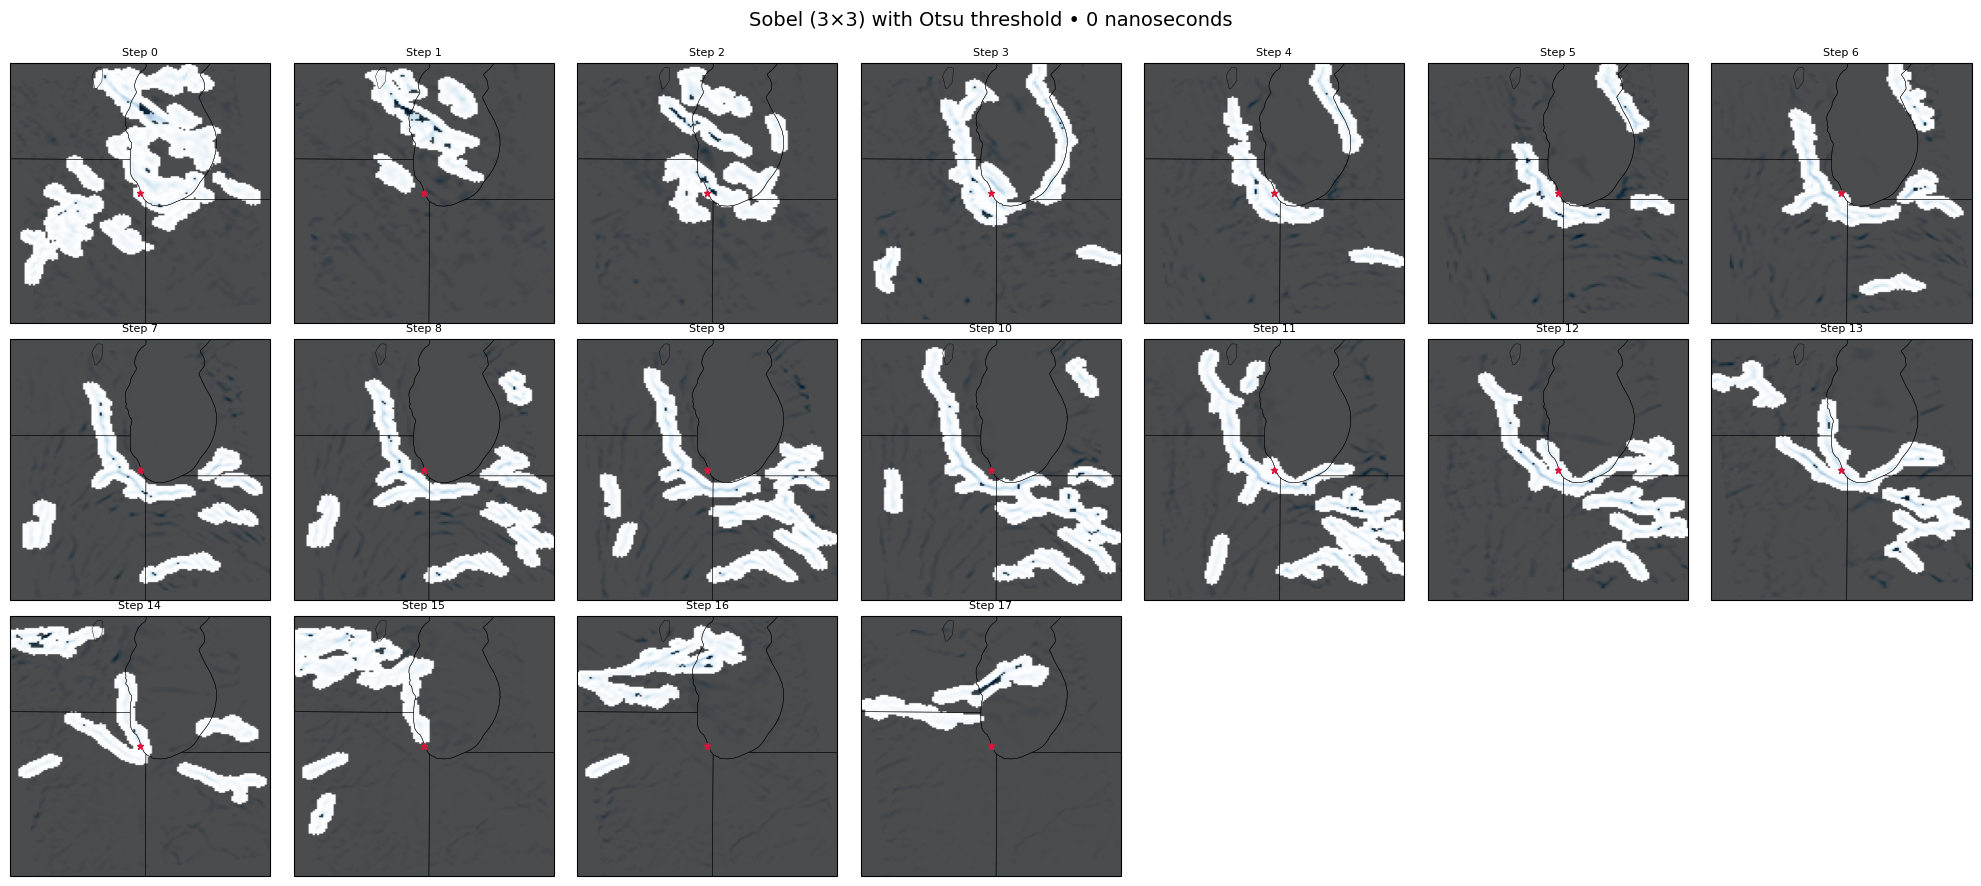

Saved: LB_SOBEL_OTSU/LB_SOBEL_OTSU_FILTERED.png


In [17]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from skimage.measure import label, regionprops

# ---------------- Config ----------------
KSIZE = 3           # Sobel kernel size
MIN_MAJOR_PX = 20   # keep only elongated components
SMOOTH_SIGMA = 0.0  # optional Gaussian blur (px)
USE_OTSU = True     # << use Otsu instead of percentile
PAD_FRAC = 0.10     # small padding (optional)

nsteps = 18
ncols  = 7
nrows  = int(np.ceil(nsteps / ncols))

center_lat, center_lon = 41.8781, -87.6298
lat_min, lat_max = center_lat - 2, center_lat + 2
lon_min, lon_max = center_lon - 2, center_lon + 2

# Optional: for title and saving
start_time = pcp['step'].values[0] if 'step' in pcp['div'].dims else "T0"
save_dir = "LB_SOBEL_OTSU"
os.makedirs(save_dir, exist_ok=True)

# ---------------- Data handles ----------------
lat2d = pcp['latitude']
lon2d = pcp['longitude']
lon_wrapped = (lon2d + 180) % 360 - 180

# ---------------- Figure ----------------
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(20, 9),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

last_i = -1
for i in range(nsteps):
    # --- Field and mask ---
    field = pcp['div'].isel(step=i)  # your original field (use thte/t2m if desired)
    mask = ((lat2d >= lat_min) & (lat2d <= lat_max) &
            (lon_wrapped >= lon_min) & (lon_wrapped <= lon_max))
    field_box = field.where(mask, drop=True)
    lat_box   = lat2d.where(mask, drop=True)
    lon_box   = lon_wrapped.where(mask, drop=True)
    if field_box.size == 0 or np.all(np.isnan(field_box)):
        continue

    # --- Convergence only (keep negative) ---
    field_conv = field_box.where(field_box < 0, 0)
    A = field_conv.values.astype(np.float32)
    if np.isnan(A).any():
        A = np.nan_to_num(A, nan=np.nanmedian(A))

    # --- Optional smoothing ---
    A_blur = cv2.GaussianBlur(A, (0, 0), SMOOTH_SIGMA) if SMOOTH_SIGMA > 0 else A

    # --- Sobel & magnitude ---
    sx = cv2.Sobel(A_blur, cv2.CV_32F, 1, 0, ksize=KSIZE)
    sy = cv2.Sobel(A_blur, cv2.CV_32F, 0, 1, ksize=KSIZE)
    mag = cv2.magnitude(sx, sy)

    # --- Otsu threshold on magnitude (needs 8-bit) ---
    # Normalize 0–255 ignoring NaNs (we ensured no NaNs above)
    mag_u8 = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    if USE_OTSU:
        # cv2.threshold returns (thresh_value, binary_img)
        _, edges_u8 = cv2.threshold(mag_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        edges_mask = edges_u8 > 0
    else:
        # fallback: fixed percentile if you want to compare
        PCT = 95
        thr = np.percentile(mag, PCT)
        edges_mask = (mag >= thr)

    # --- Label connected regions and filter by elongation ---
    labeled = label(edges_mask, connectivity=2)
    cleaned = np.zeros_like(edges_mask, dtype=np.uint8)
    for rp in regionprops(labeled):
        if rp.major_axis_length >= MIN_MAJOR_PX:
            cleaned[labeled == rp.label] = 1

    # --- Thin edge outline of kept blobs ---
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned_edges = cv2.morphologyEx(cleaned, cv2.MORPH_GRADIENT, kernel)

    # --- Plot on Cartopy axis ---
    ax = axes[i]
    xmin, xmax = float(np.nanmin(lon_box.values)), float(np.nanmax(lon_box.values))
    ymin, ymax = float(np.nanmin(lat_box.values)), float(np.nanmax(lat_box.values))

    # padding so imagery isn’t flush
    xpad = (xmax - xmin) * PAD_FRAC
    ypad = (ymax - ymin) * PAD_FRAC
    xmin -= xpad; xmax += xpad
    ymin -= ypad; ymax += ypad

    origin = 'lower'
    if lat_box.values.ndim == 2 and lat_box.shape[0] > 1 and lat_box.values[0, 0] > lat_box.values[-1, 0]:
        origin = 'upper'

    ax.imshow(A, cmap='Blues_r', origin=origin,
              extent=[xmin, xmax, ymin, ymax], transform=ccrs.PlateCarree(), aspect='auto')
    ax.imshow(cleaned_edges, cmap='gray', origin=origin, alpha=0.7,
              extent=[xmin, xmax, ymin, ymax], transform=ccrs.PlateCarree())

    # Map features
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.3)
    ax.add_feature(cfeature.LAKES.with_scale('50m'), edgecolor='k', facecolor='none', linewidth=0.3)

    ax.plot(center_lon, center_lat, marker='*', color='crimson',
            markersize=5, transform=ccrs.PlateCarree())
    ax.set_extent([xmin, xmax, ymin, ymax])
    ax.set_title(f"Step {i}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

    last_i = i

# Remove unused subplots
for j in range(last_i + 1, len(axes)):
    fig.delaxes(axes[j])

title_thr = "Otsu" if USE_OTSU else "Percentile"
fig.suptitle(f"Sobel ({KSIZE}×{KSIZE}) with {title_thr} threshold • {start_time}", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.92)

out_path = os.path.join(save_dir, f'LB_SOBEL_{title_thr.upper()}_FILTERED.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")


✅ GIF saved: lake_breeze_outputs/2025-05-10 12:00:00_LB_K3_P92.5_chi_pm2deg/gifs/lake_breeze_detection.gif  (18 frames at 2 fps)


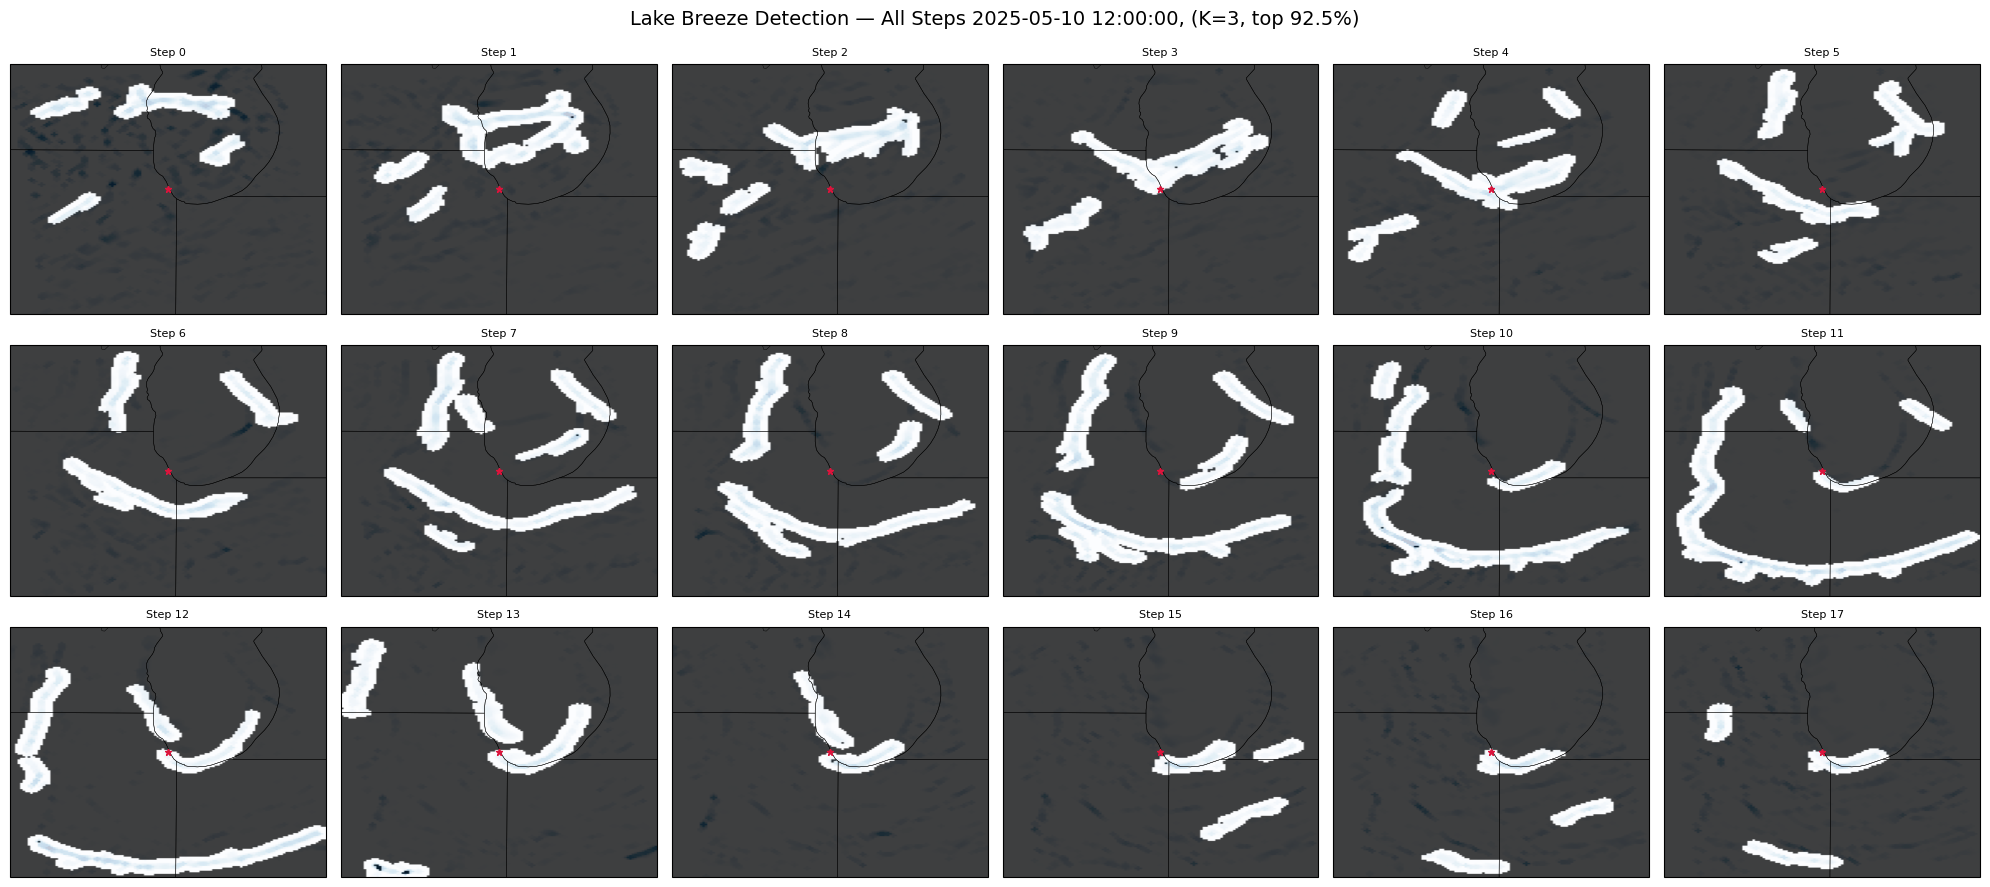

🖼️ Multipanel saved: lake_breeze_outputs/2025-05-10 12:00:00_LB_K3_P92.5_chi_pm2deg/panels/lake_breeze_multipanel.png
🗂️ Frames in: lake_breeze_outputs/2025-05-10 12:00:00_LB_K3_P92.5_chi_pm2deg/frames
🗂️ GIF in:    lake_breeze_outputs/2025-05-10 12:00:00_LB_K3_P92.5_chi_pm2deg/gifs/lake_breeze_detection.gif


In [10]:
import imageio.v2 as imageio  # pip install imageio

# -------- Params --------
KSIZE  = 3
PCT    = 92.5
nsteps = 18
FPS    = 2

# Fixed colormap range (tweak if needed)
VMIN, VMAX = -0.0008, 0.0

# -------- Output folders --------
BASE_DIR  = "lake_breeze_outputs"
run_label = f"{start_time}_LB_K{KSIZE}_P{PCT}_chi_pm2deg"
OUT_DIR   = os.path.join(BASE_DIR, run_label)
FRAMES_DIR = os.path.join(OUT_DIR, "frames")
GIF_DIR    = os.path.join(OUT_DIR, "gifs")
PANELS_DIR = os.path.join(OUT_DIR, "panels")

for d in [OUT_DIR, FRAMES_DIR, GIF_DIR, PANELS_DIR]:
    os.makedirs(d, exist_ok=True)

OUT_GIF   = os.path.join(GIF_DIR, "lake_breeze_detection.gif")
OUT_PANEL = os.path.join(PANELS_DIR, "lake_breeze_multipanel.png")

# Region mask (reused each step)
region_mask = ((lat2d >= lat_min) & (lat2d <= lat_max) &
               (lon_wrapped >= lon_min) & (lon_wrapped <= lon_max))

frames = []

# We'll also collect items for the multipanel at the end
panel_items = []  # list of dicts: {"A_closed":..., "outline":..., "extent":..., "origin":..., "step":i}

for i in range(nsteps):
    # --- Field and mask ---
    field = pcp['div'].isel(step=i)
    field_box = field.where(region_mask, drop=True)
    lat_box   = lat2d.where(region_mask, drop=True)
    lon_box   = lon_wrapped.where(region_mask, drop=True)
    if field_box.size == 0 or np.all(np.isnan(field_box)):
        continue

    # --- Convergence only ---
    field_conv = field_box.where(field_box < 0, 0)
    A = field_conv.values.astype(np.float32)
    A = np.nan_to_num(A, nan=0.0)

    # --- Morphological Closing (smooth small gaps) ---
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    A_closed = cv2.morphologyEx(A, cv2.MORPH_CLOSE, kernel_close, iterations=1)

    # --- Sobel & threshold ---
    sx = cv2.Sobel(A_closed, cv2.CV_32F, 1, 0, ksize=KSIZE)
    sy = cv2.Sobel(A_closed, cv2.CV_32F, 0, 1, ksize=KSIZE)
    mag = cv2.magnitude(sx, sy)
    thr = np.percentile(mag, PCT)
    edges_mask = (mag >= thr)

    # --- Label + keep long components ---
    labeled = label(edges_mask)
    cleaned = np.zeros_like(edges_mask, dtype=np.uint8)
    for rp in regionprops(labeled):
        if rp.major_axis_length > 20:  # pixels (use spacing=... for km if desired)
            cleaned[labeled == rp.label] = 1

    # --- Thin outline for overlay ---
    kernel_outline = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    outline = cv2.morphologyEx(cleaned, cv2.MORPH_GRADIENT, kernel_outline)

    # --- Plot single frame ---
    xmin, xmax = np.nanmin(lon_box.values), np.nanmax(lon_box.values)
    ymin, ymax = np.nanmin(lat_box.values), np.nanmax(lat_box.values)
    origin = 'lower'
    if lat_box.values.ndim == 2 and lat_box.shape[0] > 1:
        if lat_box.values[0, 0] > lat_box.values[-1, 0]:
            origin = 'upper'

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    im0 = ax.imshow(
        A_closed, cmap='Blues_r', origin=origin,
        extent=[xmin, xmax, ymin, ymax],
        transform=ccrs.PlateCarree(), aspect='auto',
        vmin=VMIN, vmax=VMAX
    )
    ax.imshow(
        outline, cmap='gray', origin=origin, alpha=0.75,
        extent=[xmin, xmax, ymin, ymax],
        transform=ccrs.PlateCarree(), aspect='auto'
    )

    # Map features
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.4)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.4)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.4)
    ax.add_feature(cfeature.LAKES.with_scale('50m'), edgecolor='k', facecolor='none', linewidth=0.4)

    ax.plot(center_lon, center_lat, marker='*', color='crimson',
            markersize=8, transform=ccrs.PlateCarree())
    ax.set_extent([xmin, xmax, ymin, ymax])
    ax.set_title(f"Lake Breeze Detection — Step {i} | Sobel k={KSIZE}, top {PCT}%", fontsize=11)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

    cbar = plt.colorbar(im0, ax=ax, orientation='vertical', shrink=0.85, pad=0.02)
    cbar.set_label("Divergence (1/s) — convergence only")

    plt.tight_layout()

    # Save the frame PNG to its folder
    frame_png_path = os.path.join(FRAMES_DIR, f"frame_step_{i:02d}.png")
    plt.savefig(frame_png_path, dpi=200, bbox_inches='tight')

    # Capture frame for GIF, then close
    fig.canvas.draw()
    frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(frame)
    plt.close(fig)

    # Stash for multipanel later
    panel_items.append({
        "A_closed": A_closed,
        "outline": outline,
        "extent": (xmin, xmax, ymin, ymax),
        "origin": origin,
        "step": i
    })

# --- Save GIF ---
if not frames:
    raise RuntimeError("No frames generated. Check region mask or data.")
imageio.mimsave(OUT_GIF, frames, fps=FPS, loop=0)
print(f"✅ GIF saved: {OUT_GIF}  ({len(frames)} frames at {FPS} fps)")

# ---------- Multipanel (all steps) ----------
# Layout
# ---------- Multipanel (all steps) ----------
mp_cols = 6
mp_rows = int(np.ceil(len(panel_items) / mp_cols))
fig_mp, axes_mp = plt.subplots(
    nrows=mp_rows, ncols=mp_cols, figsize=(20, 9),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes_mp = np.array(axes_mp).reshape(mp_rows, mp_cols)

idx = 0
for r in range(mp_rows):
    for c in range(mp_cols):
        ax = axes_mp[r, c]
        if idx < len(panel_items):
            item = panel_items[idx]
            xmin, xmax, ymin, ymax = item["extent"]
            origin = item["origin"]
            A_closed = item["A_closed"]
            outline  = item["outline"]
            step     = item["step"]

            ax.imshow(
                A_closed, cmap='Blues_r', origin=origin,
                extent=[xmin, xmax, ymin, ymax],
                transform=ccrs.PlateCarree(), aspect='auto',
                vmin=VMIN, vmax=VMAX
            )
            ax.imshow(
                outline, cmap='gray', origin=origin, alpha=0.75,
                extent=[xmin, xmax, ymin, ymax],
                transform=ccrs.PlateCarree(), aspect='auto'
            )

            ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.3)
            ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.3)
            ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.3)
            ax.add_feature(cfeature.LAKES.with_scale('50m'), edgecolor='k', facecolor='none', linewidth=0.3)
            ax.plot(center_lon, center_lat, marker='*', color='crimson',
                    markersize=5, transform=ccrs.PlateCarree())
            ax.set_extent([xmin, xmax, ymin, ymax])
            ax.set_title(f"Step {step}", fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            fig_mp.delaxes(ax)
        idx += 1

# No shared colorbar here
fig_mp.suptitle(f"Lake Breeze Detection — All Steps {start_time}, (K={KSIZE}, top {PCT}%)", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig(OUT_PANEL, dpi=300, bbox_inches='tight')
plt.show()

print(f"Multipanel saved: {OUT_PANEL}")
print(f"Frames in: {FRAMES_DIR}")
print(f"GIF in:    {OUT_GIF}")

